Error procesando la línea: Learning Rate: 0.067


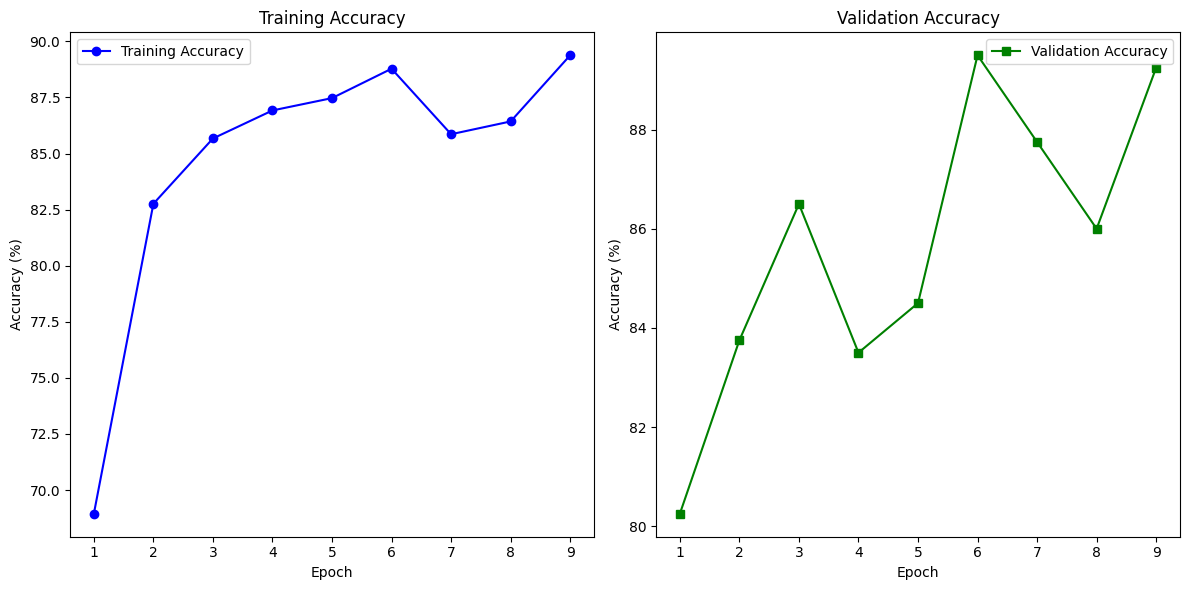

In [13]:
import matplotlib.pyplot as plt

# Nombres de los archivos
files = [
    "C:\\Users\\Usuario\\Documents\\Maestria\\courses\\CSE705\\Project\\results_lr_0.067_augmented_static.txt",
]

# Learning rates correspondientes
learning_rates = [0, 0.15]

# Diccionario para almacenar los datos
data = {}

# Leer datos desde los archivos
for file in files:
    data= {"training": [], "validation": []}
    with open(file, "r") as f:
        lines = f.readlines()
        for line in lines:
            line = line.strip()  # Elimina espacios en blanco iniciales y finales
            if not line:  # Salta líneas vacías
                continue
            # Verificar que la línea tiene exactamente 3 partes
            parts = line.split()
            if len(parts) == 3:
                try:
                    epoch, train_acc, val_acc = map(float, parts)
                    data["training"].append(train_acc)
                    data["validation"].append(val_acc)
                except ValueError:
                    print(f"Error procesando la línea: {line}")
                    continue
# Crear una figura con 1 fila y 2 columnas
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))  # Ajusta figsize según sea necesario

# Subgráfico para Training Accuracy
ax_train = axs[0]
ax_train.plot(
    range(1, len(data["training"]) + 1),
    data["training"],
    label="Training Accuracy",
    color="blue",
    marker="o",
)
ax_train.set_title("Training Accuracy")
ax_train.set_xlabel("Epoch")
ax_train.set_ylabel("Accuracy (%)")
ax_train.legend()
ax_train.grid(False)

# Subgráfico para Validation Accuracy
ax_val = axs[1]
ax_val.plot(
    range(1, len(data["validation"]) + 1),
    data["validation"],
    label="Validation Accuracy",
    color="green",
    marker="s",
)
ax_val.set_title("Validation Accuracy")
ax_val.set_xlabel("Epoch")
ax_val.set_ylabel("Accuracy (%)")
ax_val.legend()
ax_val.grid(False)

# Ajustar la distribución de subgráficos
plt.tight_layout()

# Guardar y mostrar la figura
plt.savefig("comparison_accuracy_results.png")
plt.show()